<a href="https://colab.research.google.com/github/AndrewP05/Kmeans_estados_inseguridad/blob/main/kmeans_estados_inseguridad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Inseguridad por Estados usando K-Means

**Objetivo:** El propósito de este cuaderno es agrupar (clusterizar) estados según sus índices de criminalidad y características demográficas.

Para lograrlo, utilizaremos el algoritmo de aprendizaje no supervisado **K-Means**, analizando las siguientes variables:
* `Murder`: Tasa de asesinatos.
* `Assault`: Tasa de asaltos.
* `Rape`: Tasa de violaciones.
* `UrbanPop`: Porcentaje de población urbana.

## 1. Configuración del Entorno
Dado que estamos trabajando en Google Colab, el primer paso es montar nuestro Google Drive para poder acceder a los directorios y archivos de datos necesarios para el análisis.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Importación de Librerías
Importamos las herramientas fundamentales para nuestro análisis:
* **Manipulación de datos:** `pandas`, `numpy`.
* **Visualización:** `matplotlib`, `seaborn`, `Axes3D` (para gráficos en 3D).
* **Machine Learning (Scikit-Learn):** `KMeans` (para el algoritmo de agrupamiento), `MaxAbsScaler` (para normalizar la escala de los datos) y `silhouette_score` (para evaluar la calidad y cohesión de los clusters formados).

In [ ]:
import pandas as pd
from sklearn.preprocessing import MaxAbsScaler
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

## 3. Carga y Exploración Inicial de los Datos
Cargamos el dataset `datos_estados.csv` que contiene las métricas de inseguridad por cada estado. Utilizamos la función `head()` para visualizar las primeras filas y comprobar que las variables numéricas y los nombres de los estados se han cargado correctamente.

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Semestre 10/IA para las organizaciones/IA_Organizaciones_2026_Estudiantes/Sem6/datos_estados.csv')
data.head()

,Estado,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


## 4. Preprocesamiento: Escalado de los Datos
Los algoritmos basados en cálculo de distancias (como K-Means) son muy sensibles a las diferencias de proporciones numéricas. Si una variable tiene valores absolutos mucho más altos que otras (por ejemplo, `Assault` suele tener valores de cientos, frente a `Murder` que tiene decenas), la variable mayor dominará la asignación de los clusters.

Para evitar este sesgo, aplicamos `MaxAbsScaler`. Esta técnica escala cada característica dividiéndola por su valor máximo absoluto, dejando todas las variables numéricas en un rango equilibrado (hasta 1.0). Finalmente, reconstruimos el DataFrame manteniendo la columna categórica `Estado`.

In [ ]:
scaler_object = MaxAbsScaler()

data_to_scale = data[['Murder', 'Assault', 'UrbanPop', 'Rape']]
scaler_object.fit(data_to_scale)

scaled_data = scaler_object.transform(data_to_scale)

data_to_scale = pd.DataFrame(scaled_data, columns=data_to_scale.columns)

data_to_scale['Estado'] = data['Estado']
data = data_to_scale.copy()

data.head()

,Murder,Assault,UrbanPop,Rape,Estado
0,0.758621,0.700297,0.637363,0.460870,Alabama
1,0.574713,0.780415,0.527473,0.967391,Alaska
2,0.465517,0.872404,0.879121,0.673913,Arizona
3,0.505747,0.563798,0.549451,0.423913,Arkansas
4,0.517241,0.818991,1.000000,0.882609,California


## 5. Construcción del Modelo K-Means y Visualización
En esta fase determinamos la cantidad adecuada de clusters (evaluando métricas como el coeficiente de silueta) y procedemos a ajustar el modelo K-Means con nuestros datos escalados. Posteriormente, representaremos gráficamente la separación de los estados.

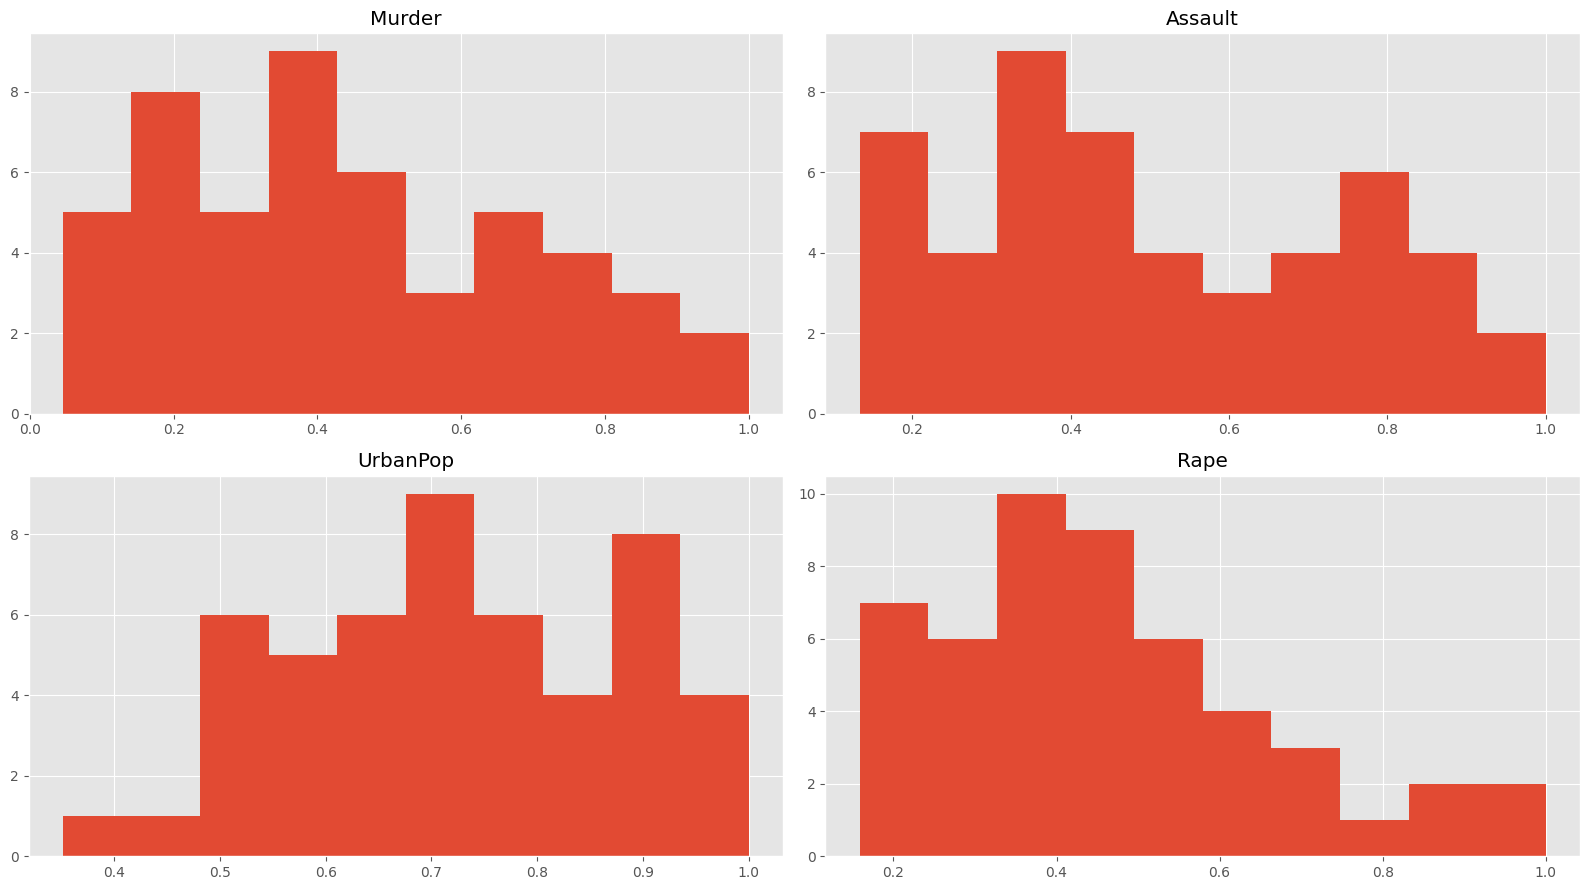

In [ ]:
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')

data.drop('Estado', axis='columns').hist()

plt.tight_layout()
plt.show()

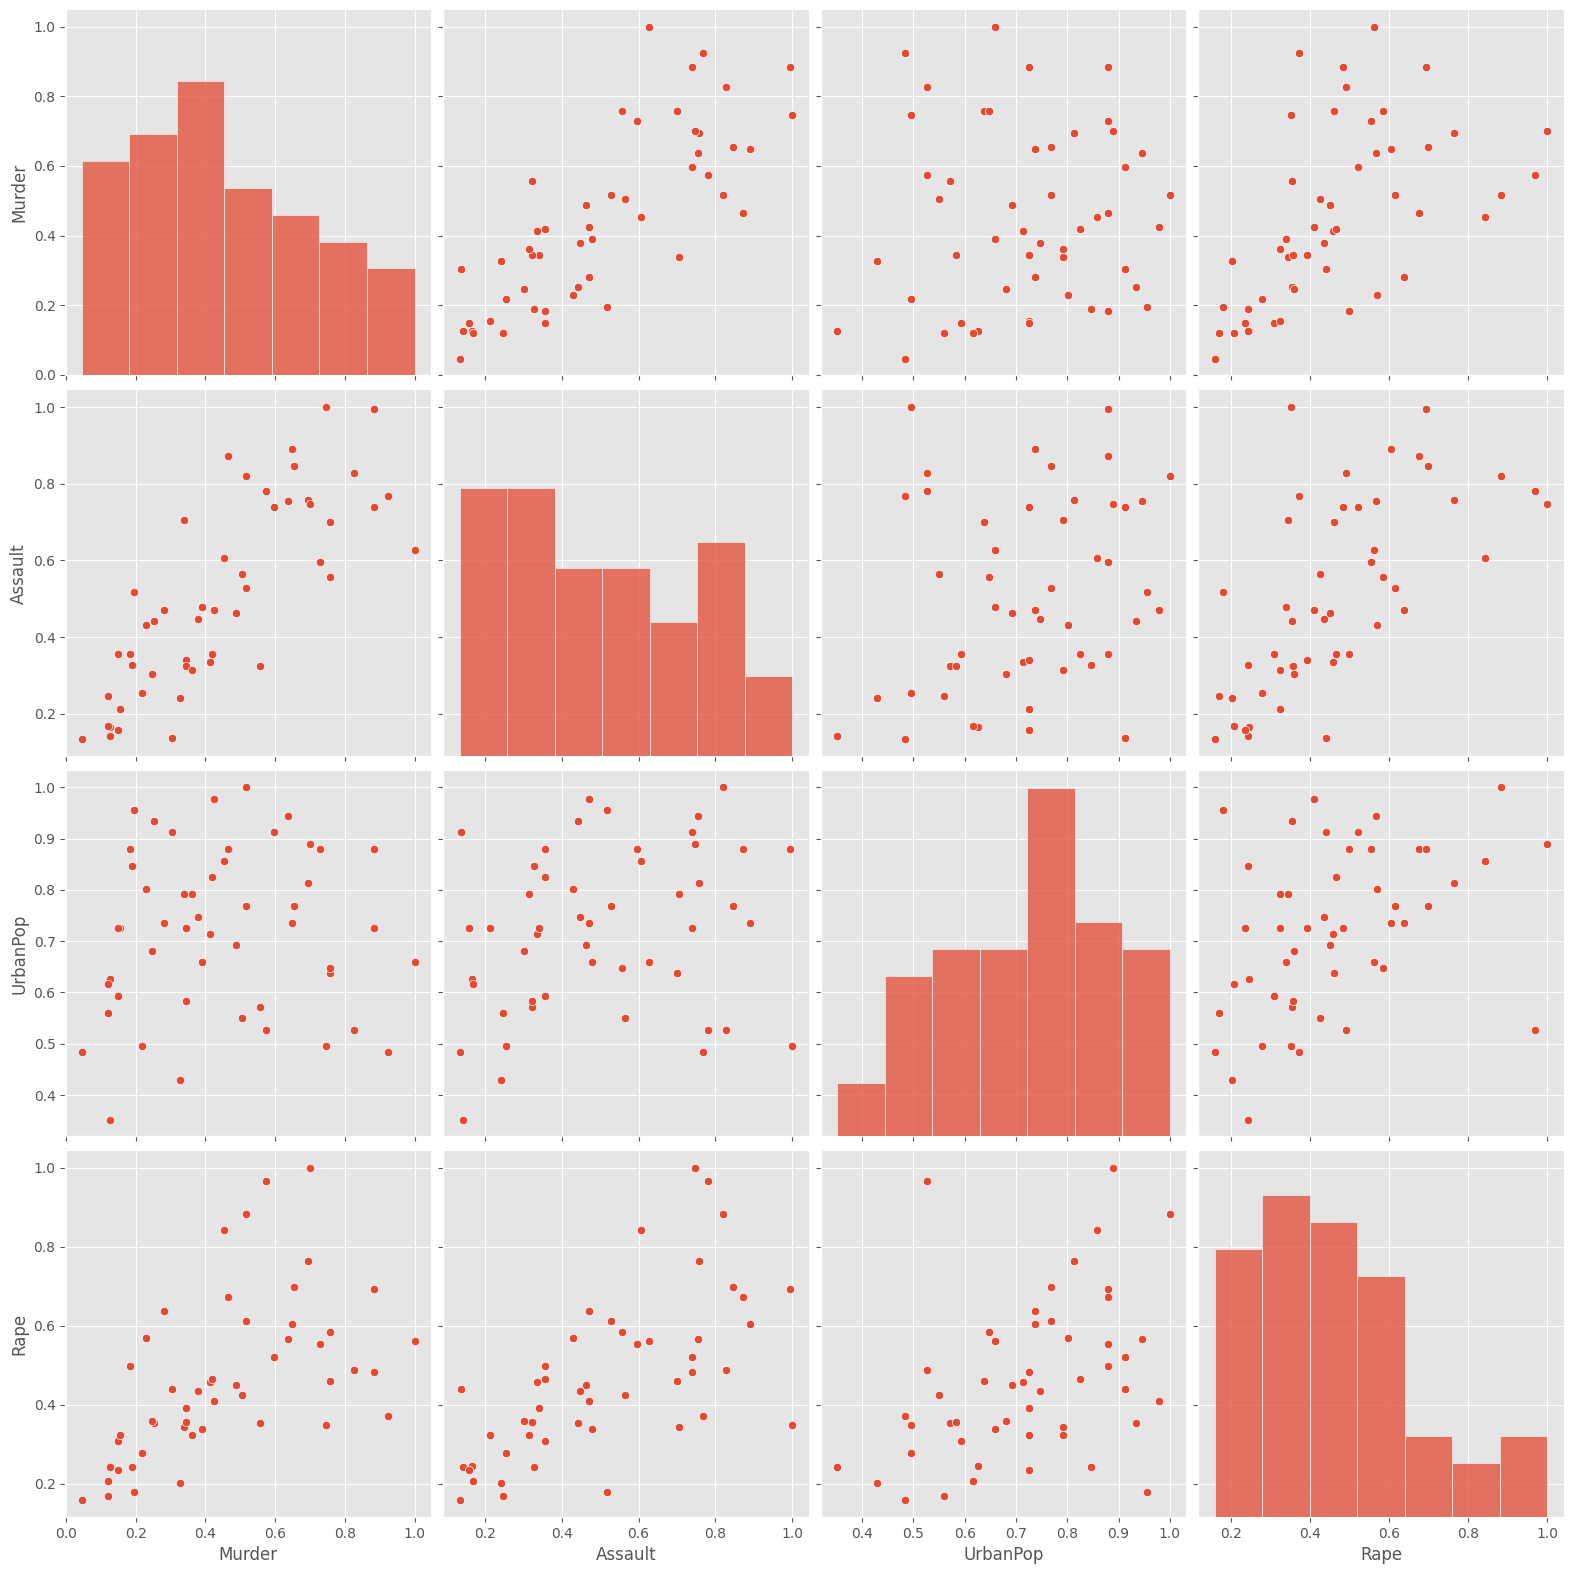

In [ ]:
sb.pairplot(data.dropna(), height=4, vars=["Murder", "Assault", "UrbanPop", "Rape"], kind='scatter')

In [ ]:
X = np.array(data[["Murder", "Assault", "UrbanPop", "Rape"]])
kmeans = KMeans(n_clusters=4, random_state=0).fit(X)
centroids = kmeans.cluster_centers_

labels = kmeans.predict(X)
labels

array([2, 0, 0, 3, 0, 0, 1, 3, 0, 2, 3, 1, 0, 3, 1, 3, 3, 2, 1, 0, 3, 0,
       1, 2, 3, 1, 1, 0, 1, 3, 0, 0, 2, 1, 3, 3, 3, 3, 3, 2, 1, 2, 0, 3,
       1, 3, 3, 1, 1, 3], dtype=int32)

In [ ]:
C = kmeans.cluster_centers_
colores=['red','green','blue','cyan','yellow']
asignar=[]
for row in labels:
    asignar.append(colores[row])

fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=asignar,s=60)

<Figure size 1600x900 with 0 Axes>

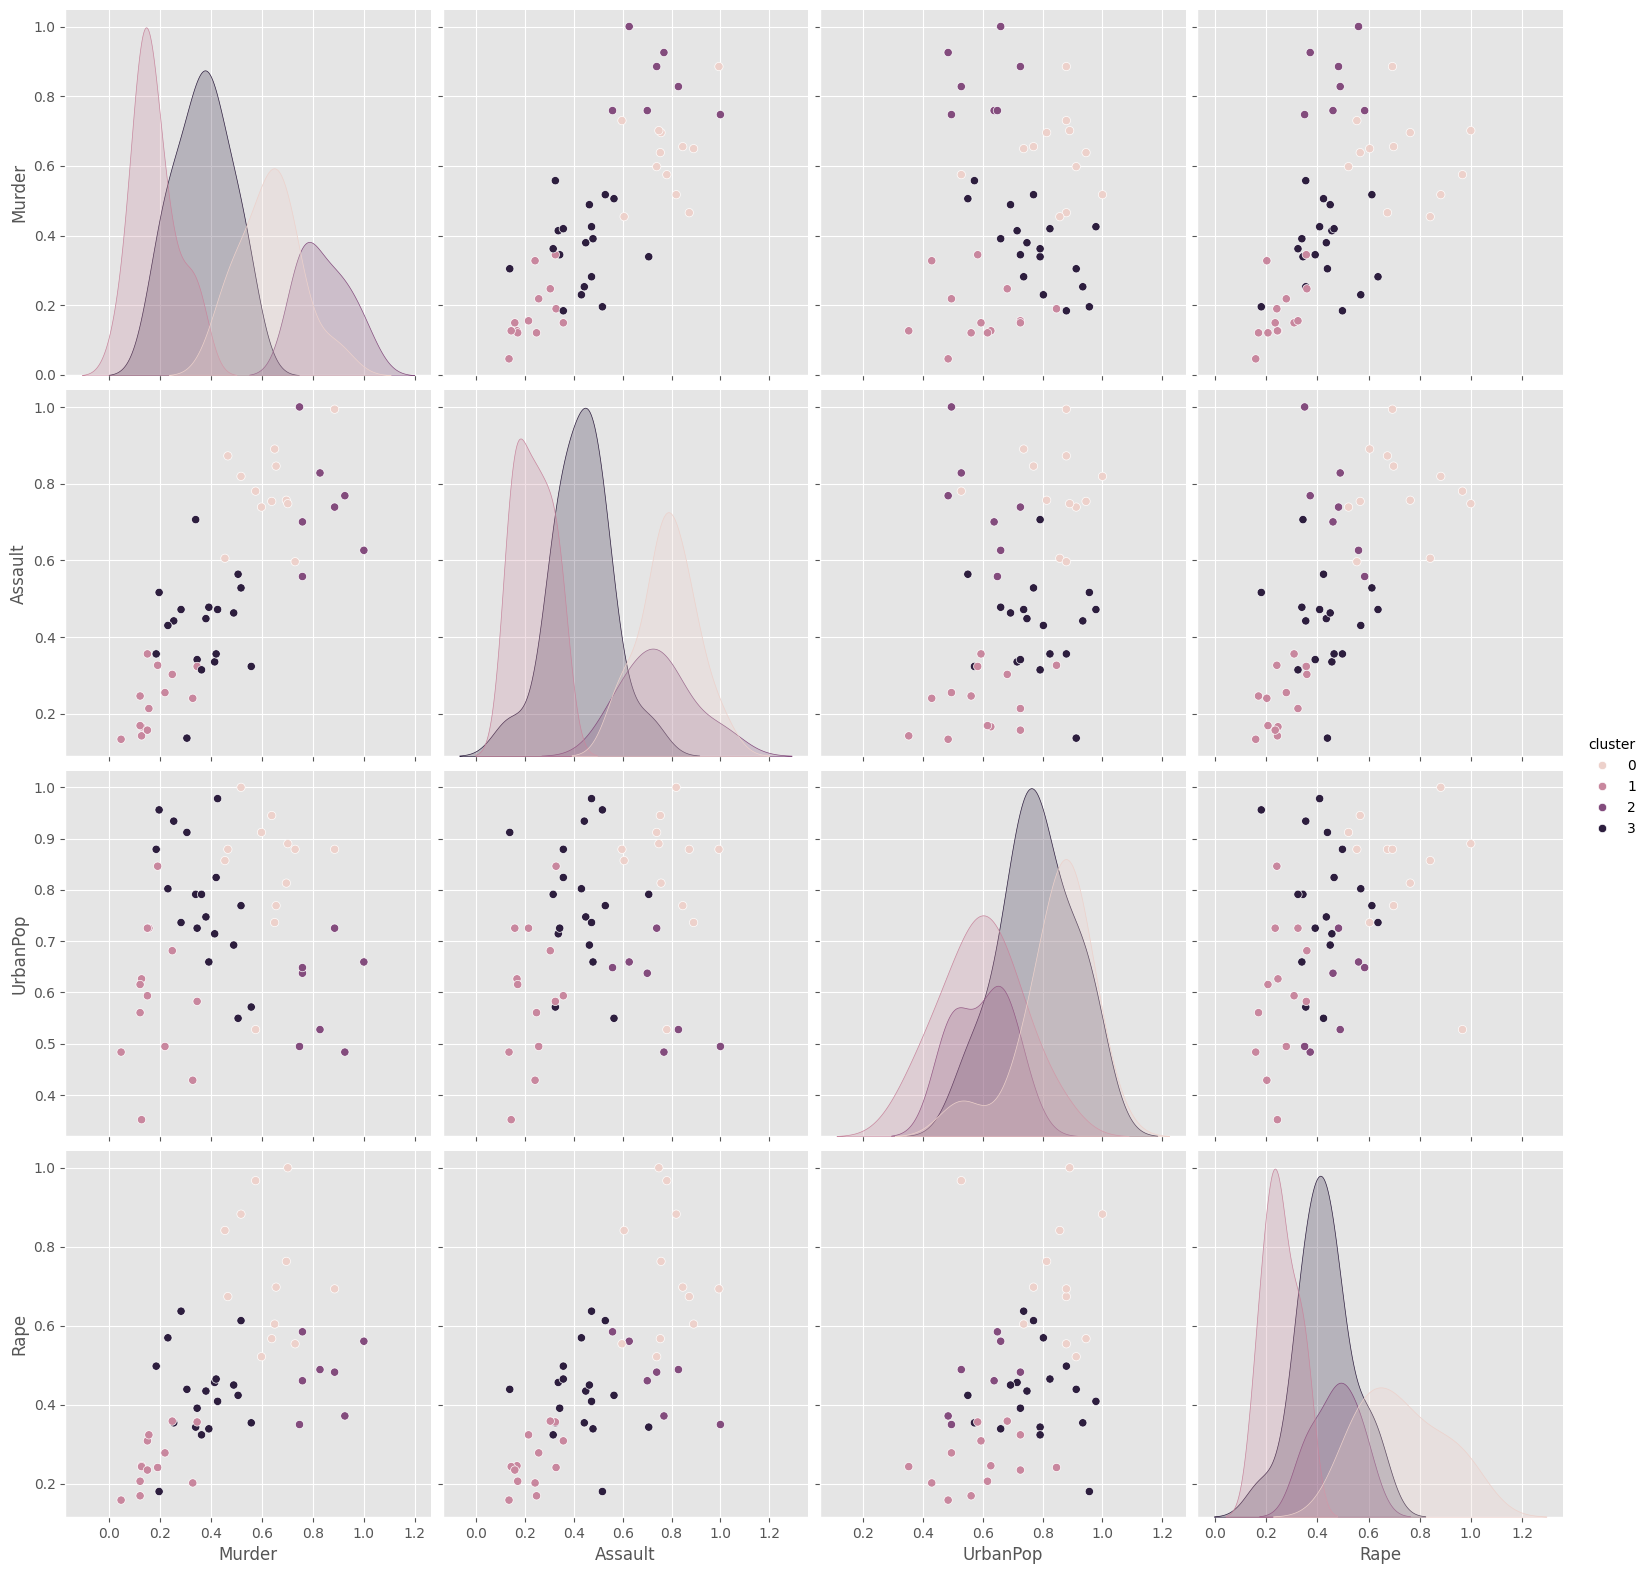

In [ ]:
data['cluster'] = labels

sb.pairplot(data.dropna(), hue='cluster', height=4, vars=["Murder", "Assault", "UrbanPop", "Rape"], kind='scatter')

## K óptimo

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


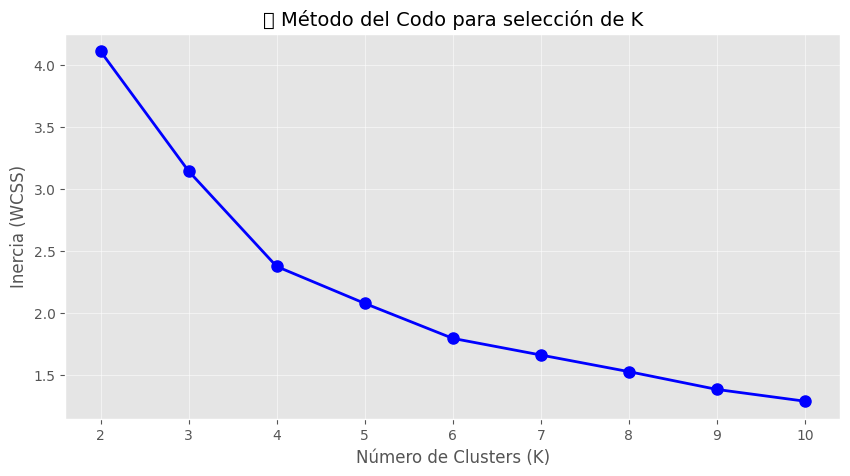

💡 Busca el 'codo': punto donde la inercia deja de bajar significativamente.


In [ ]:
# Método del Codo

inercias = []
rango_k = range(2, 11)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inercias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(rango_k, inercias, 'bo-', markersize=8, linewidth=2)
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Inercia (WCSS)', fontsize=12)
plt.title('📐 Método del Codo para selección de K', fontsize=14)
plt.xticks(rango_k)
plt.grid(True, alpha=0.5)
plt.show()

print("💡 Busca el 'codo': punto donde la inercia deja de bajar significativamente.")


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


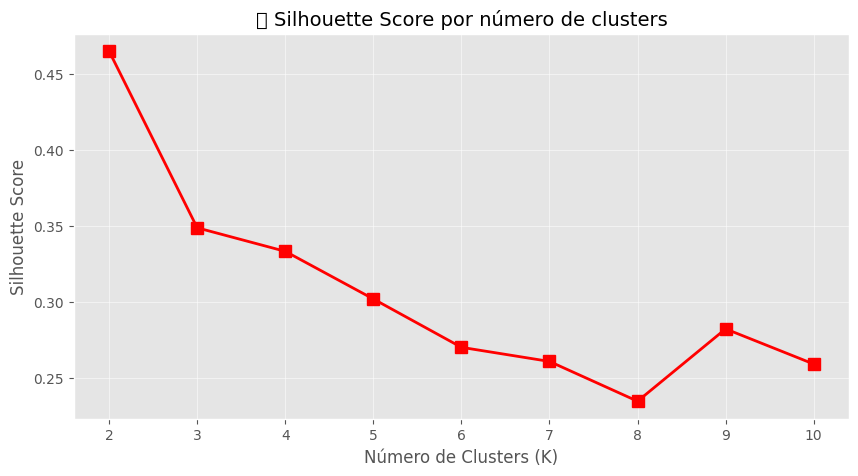

 K  Inercia  Silhouette
 2 4.109291      0.4650
 3 3.143390      0.3488
 4 2.374668      0.3333
 5 2.077185      0.3020
 6 1.795053      0.2701
 7 1.660860      0.2608
 8 1.526846      0.2347
 9 1.383339      0.2823
10 1.288462      0.2591

✅ K óptimo sugerido por Silhouette: K=2


In [ ]:
# Silhouette score
# Más cercano a 1 es mejor

silhouette_scores = []

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = km.fit_predict(X)
    score = silhouette_score(X, labels_temp)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(rango_k, silhouette_scores, 'rs-', markersize=8, linewidth=2)
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('📏 Silhouette Score por número de clusters', fontsize=14)
plt.xticks(rango_k)
plt.grid(True, alpha=0.5)
plt.show()

# Tabla resumen
resultados_k = pd.DataFrame({
    'K': list(rango_k),
    'Inercia': inercias,
    'Silhouette': [round(s, 4) for s in silhouette_scores]
})
print(resultados_k.to_string(index=False))
print(f"\n✅ K óptimo sugerido por Silhouette: K={rango_k[silhouette_scores.index(max(silhouette_scores))]}")


In [ ]:
# Modelo K-Means Final


K_OPTIMO = 2

kmeans_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
labels = kmeans_final.fit_predict(X)

# Agregar etiquetas al dataframe
data_resultado = data.copy()
data_resultado['Cluster'] = labels

print(f"Modelo entrenado con K={K_OPTIMO}")
print(f"Distribución de estados por cluster:")
print(data_resultado['Cluster'].value_counts().sort_index())


Modelo entrenado con K=2
Distribución de estados por cluster:
Cluster
0    30
1    20
Name: count, dtype: int64


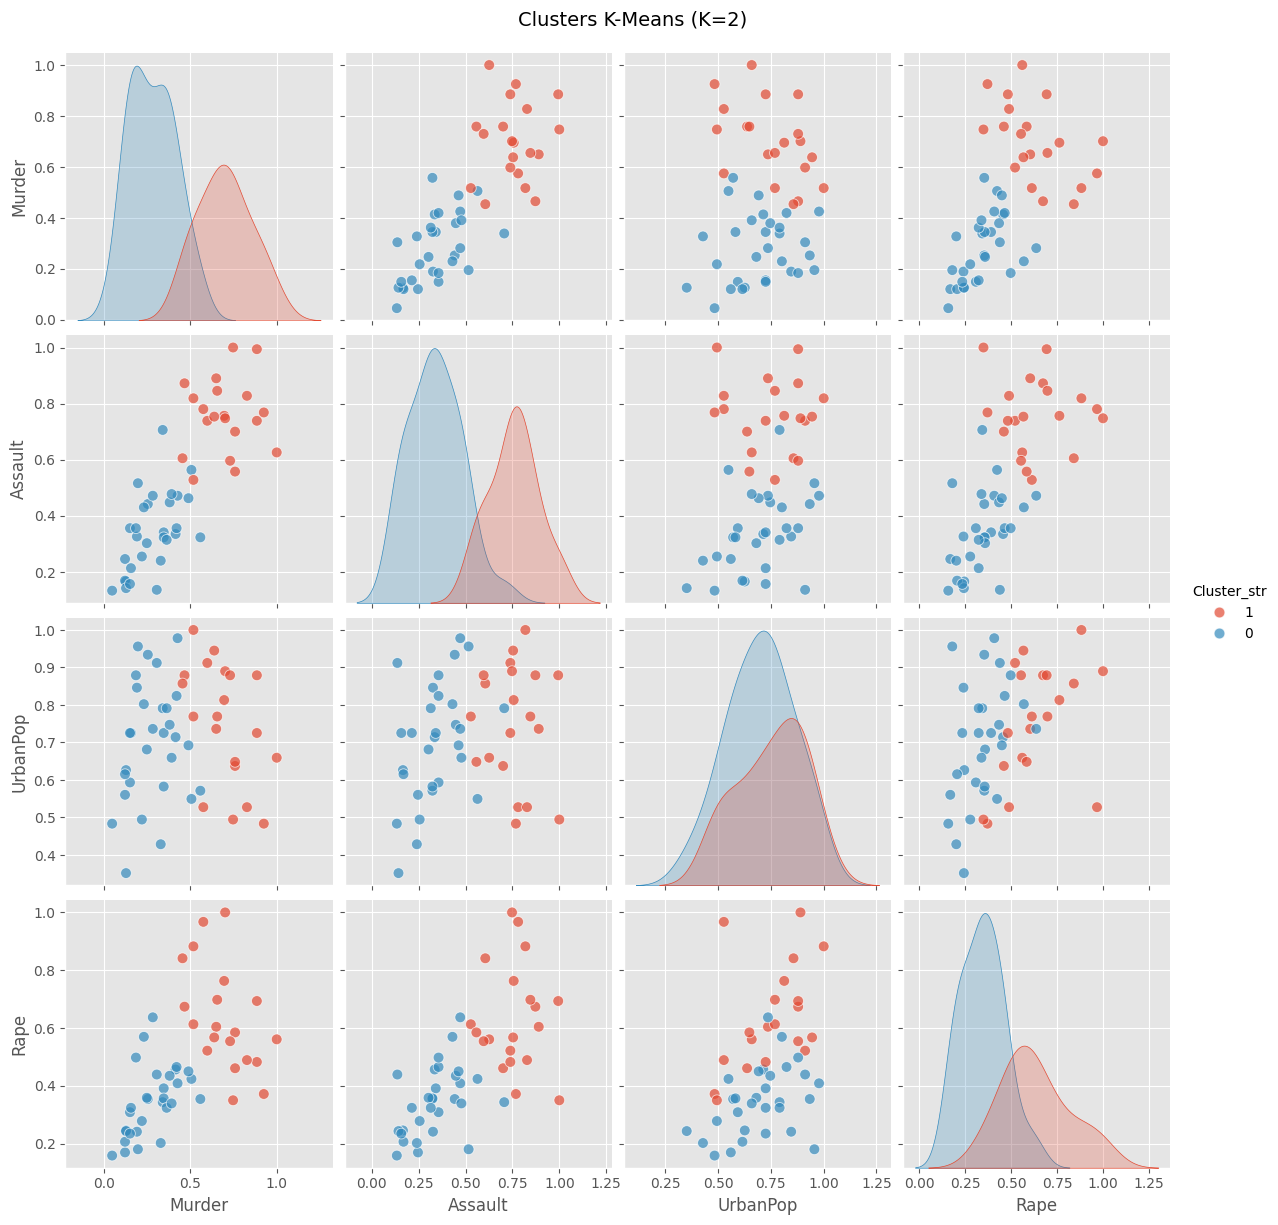

In [ ]:
variables = ["Murder", "Assault", "UrbanPop", "Rape"]

# Agregar columna cluster al dataframe
data_resultado = data.copy()
data_resultado['Cluster'] = labels
data_resultado['Cluster_str'] = data_resultado['Cluster'].astype(str)

# Pairplot con clusters
sb.pairplot(
    data_resultado.dropna(),
    hue='Cluster_str',
    height=3,
    vars=variables,
    kind='scatter',
    plot_kws={'alpha': 0.7, 's': 60}
)

plt.suptitle(f'Clusters K-Means (K={K_OPTIMO})', y=1.02, fontsize=14)
plt.show()


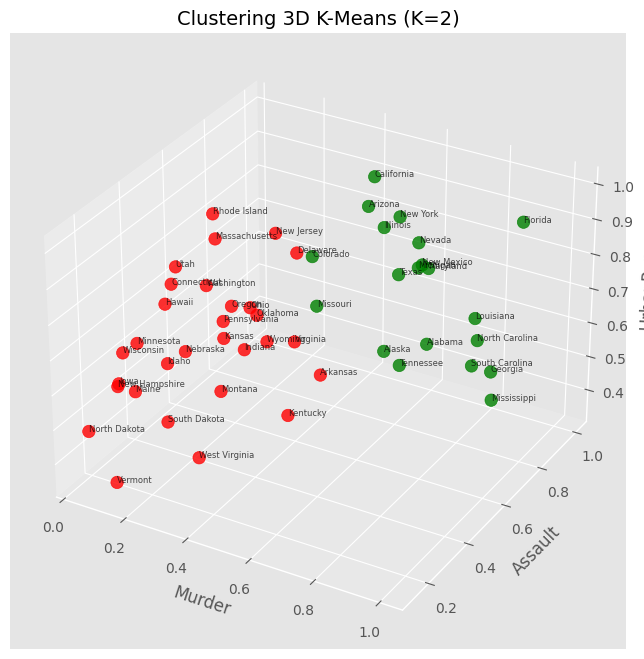

In [ ]:
# Visualización 3D

colores_lista = ['red','green','blue','orange','purple']
colores_asignados = [colores_lista[l] for l in labels]

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2],
                     c=colores_asignados, s=80, alpha=0.8)

# Etiquetas de estados
for i, estado in enumerate(data['Estado']):
    ax.text(X[i,0], X[i,1], X[i,2], estado, fontsize=6, alpha=0.7)

ax.set_xlabel('Murder')
ax.set_ylabel('Assault')
ax.set_zlabel('UrbanPop')
ax.set_title(f'Clustering 3D K-Means (K={K_OPTIMO})', fontsize=14)
plt.show()


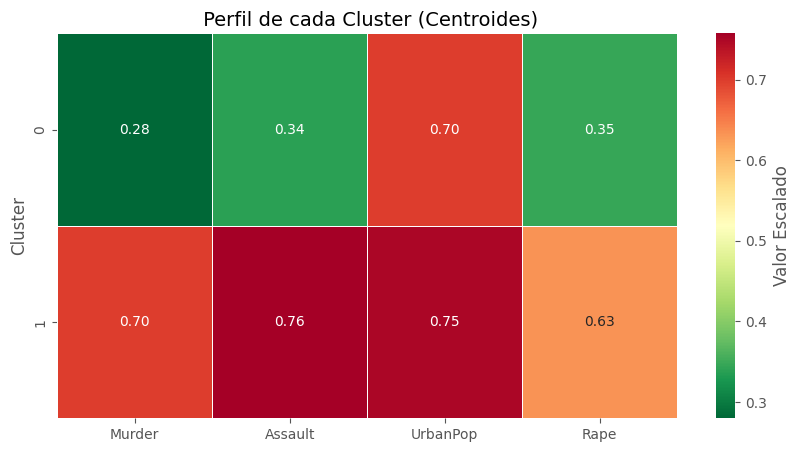

In [ ]:
# # Heatmap de centroides

# Pasar kmean_final a centroids
centroids = pd.DataFrame(kmeans_final.cluster_centers_, columns=variables)
plt.figure(figsize=(10, 5))
sb.heatmap(centroids, annot=True, cmap='RdYlGn_r',
            fmt='.2f', linewidths=0.5,
            cbar_kws={'label': 'Valor Escalado'})
plt.title(' Perfil de cada Cluster (Centroides)', fontsize=14)
plt.ylabel('Cluster')
plt.show()

## 6. Interpretación de los Clusters
Una vez que el modelo ha asignado cada estado a un grupo (columna `Cluster`), procedemos a interpretar qué representa cada uno.
En esta sección imprimimos los estados que conforman cada cluster y extraemos las **estadísticas promedio** (`Murder`, `Assault`, `UrbanPop`, `Rape`). Esto es vital para asignarle un "perfil" a cada grupo (por ejemplo: "Estados de altísima criminalidad" vs. "Estados seguros con baja población urbana").

In [ ]:
# Interpretación de Clusters

print("ESTADOS POR CLUSTER")
print("-"*60)

for cluster_id in sorted(data_resultado['Cluster'].unique()):
    estados = data_resultado[data_resultado['Cluster'] == cluster_id]['Estado'].tolist()
    print(f"\n Cluster {cluster_id} ({len(estados)} estados):")
    print(", ".join(estados))

    # Estadísticas del cluster
    stats = data_resultado[data_resultado['Cluster'] == cluster_id][variables].mean()
    print(f"   Promedio Murder: {stats['Murder']:.3f} | Assault: {stats['Assault']:.3f}")
    print(f"   Promedio UrbanPop: {stats['UrbanPop']:.3f} | Rape: {stats['Rape']:.3f}")


ESTADOS POR CLUSTER
------------------------------------------------------------

 Cluster 0 (30 estados):
Arkansas, Connecticut, Delaware, Hawaii, Idaho, Indiana, Iowa, Kansas, Kentucky, Maine, Massachusetts, Minnesota, Montana, Nebraska, New Hampshire, New Jersey, North Dakota, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, South Dakota, Utah, Vermont, Virginia, Washington, West Virginia, Wisconsin, Wyoming
   Promedio Murder: 0.280 | Assault: 0.340
   Promedio UrbanPop: 0.699 | Rape: 0.347

 Cluster 1 (20 estados):
Alabama, Alaska, Arizona, California, Colorado, Florida, Georgia, Illinois, Louisiana, Maryland, Michigan, Mississippi, Missouri, Nevada, New Mexico, New York, North Carolina, South Carolina, Tennessee, Texas
   Promedio Murder: 0.699 | Assault: 0.757
   Promedio UrbanPop: 0.752 | Rape: 0.634


## 7. Conclusión y Hallazgos Principales

Tras aplicar el algoritmo de **K-Means** a nuestro conjunto de datos de criminalidad por estados, hemos logrado segmentar el país en grupos distintos con características muy marcadas. El uso de la escala máxima absoluta (`MaxAbsScaler`) fue fundamental para garantizar que delitos con altas tasas, como los asaltos, no opacaran a otros crímenes graves pero numéricamente menores, como los asesinatos.

A partir de las estadísticas promedio de cada cluster, podemos concluir lo siguiente:

1. **Relación entre Población Urbana y Delito:** El análisis revela una tendencia interesante entre la variable `UrbanPop` y las tasas de criminalidad. Los clusters con mayor proporción de población urbana tienden a presentar tasas notablemente más altas en delitos como asaltos (`Assault`) y violaciones (`Rape`), sugiriendo que las áreas metropolitanas enfrentan desafíos de seguridad diferentes a las zonas rurales.
   
2. **Identificación de Zonas Críticas:** El modelo logró agrupar exitosamente a los estados con los índices más preocupantes de criminalidad (como lo demuestra el cluster con promedios altos de `Murder` y `Assault`). Estos son los estados que requerirían mayor atención en políticas públicas de seguridad.

3. **Zonas de Mayor Seguridad:** En contraste, el algoritmo también agrupó aquellos estados que destacan por sus bajas tasas en todos los delitos, sirviendo como posibles modelos de estudio para entender qué políticas preventivas están funcionando.

**Reflexión Final:**
El aprendizaje no supervisado (K-Means) demostró ser una herramienta muy eficaz para descubrir patrones subyacentes en datos sociodemográficos y de seguridad. Esta clusterización proporciona una base sólida para que los tomadores de decisiones puedan asignar recursos de seguridad y estrategias de prevención de forma más focalizada, entendiendo que el perfil criminal varía drásticamente de un grupo de estados a otro.